# Deep LDA Results

Compare DNLLLoss vs LogisticLoss on CIFAR-10 and CIFAR-100 across 5 runs.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})


In [2]:
results_paths = {
    'CIFAR-10': Path('cifar10_lda_runs.json'),
    'CIFAR-100': Path('cifar100_lda_runs.json'),
}
results_by_dataset = {}
for dataset_name, results_path in results_paths.items():
    with results_path.open() as f:
        results_by_dataset[dataset_name] = json.load(f)

ylims = {
    'CIFAR-10': (80, 95),
    'CIFAR-100': (55, 70),
}


train_ylims = {
    'CIFAR-10': (90, 100),
    'CIFAR-100': (50, 100),
}
{name: results['config'] for name, results in results_by_dataset.items()}


{'CIFAR-10': {'dataset': 'CIFAR-10',
  'epochs': 100,
  'runs': 5,
  'batch_size': 256,
  'test_batch_size': 1024,
  'num_classes': 10,
  'embedding_dim': 9,
  'covariance_type': 'spherical',
  'optimizer': 'Adam',
  'lr': 0.001,
  'lambda_reg': 1.0,
  'seed_base': 1234,
  'deterministic': False,
  'device': 'cuda',
  'timestamp': '2026-01-08T16:53:35'},
 'CIFAR-100': {'dataset': 'CIFAR-100',
  'epochs': 100,
  'runs': 5,
  'batch_size': 256,
  'test_batch_size': 1024,
  'num_classes': 100,
  'embedding_dim': 99,
  'optimizer': 'Adam',
  'lr': 0.001,
  'lambda_reg': 1.0,
  'seed_base': 1234,
  'deterministic': False,
  'device': 'cuda',
  'timestamp': '2026-01-12T20:37:13'}}

In [3]:
def stack_metric(loss_runs, key):
    return np.array([run[key] for run in loss_runs], dtype=np.float32)

def summarize_metric(loss_runs, key):
    values = stack_metric(loss_runs, key)
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    return mean, std

def plot_metric(ax, loss_runs, key, label, color):
    mean, std = summarize_metric(loss_runs, key)
    epochs = np.arange(1, len(mean) + 1)
    scale = 100 if key.endswith('acc') else 1
    ax.plot(epochs, mean * scale, label=label, color=color, linewidth=2)
    ax.fill_between(epochs, (mean - std) * scale, (mean + std) * scale, color=color, alpha=0.2)
    return mean, std


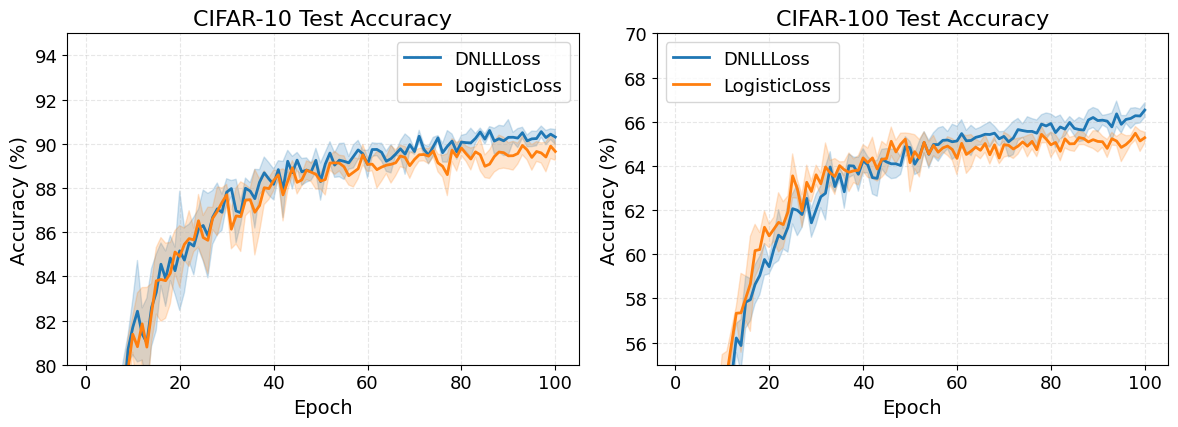

In [4]:
colors = {
    'DNLLLoss': '#1f77b4',
    'LogisticLoss': '#ff7f0e',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, (dataset_name, results) in zip(axes, results_by_dataset.items()):
    losses = results['losses']
    for loss_name, loss_runs in losses.items():
        plot_metric(ax, loss_runs, 'test_acc', loss_name, colors[loss_name])
    ax.set_title(f'{dataset_name} Test Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(ylims[dataset_name])
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('lda_runs_comparison.png', dpi=600)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

results = results_by_dataset['CIFAR-100']
losses = results['losses']
for loss_name, loss_runs in losses.items():
    plot_metric(ax, loss_runs, 'train_acc', loss_name, colors[loss_name])
ax.set_title('CIFAR-100 Train Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(train_ylims['CIFAR-100'])
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('cifar100_lda_train_accuracy.png', dpi=600)


/tmp/ipykernel_1175204/515506128.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
/tmp/ipykernel_1175204/515506128.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])


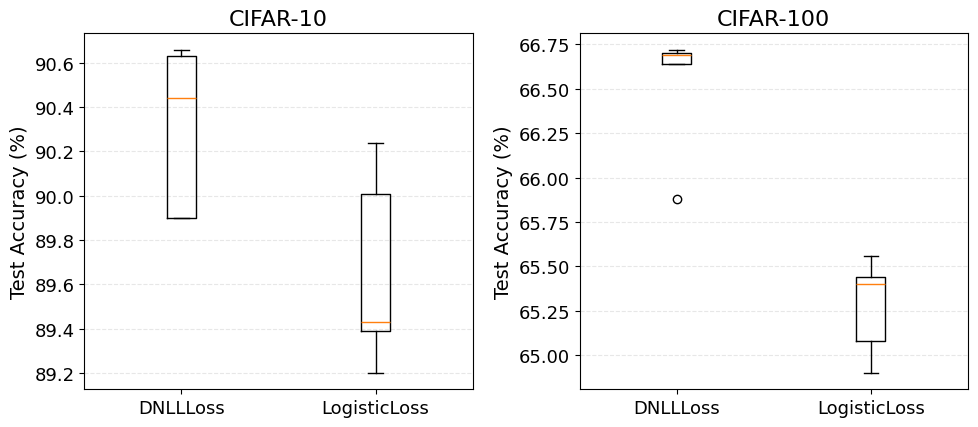

In [6]:
def final_accuracy(loss_runs, key):
    values = stack_metric(loss_runs, key)
    scale = 100 if key.endswith('acc') else 1
    return values[:, -1] * scale

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)

for ax, (dataset_name, results) in zip(axes, results_by_dataset.items()):
    losses = results['losses']
    dnll_final = final_accuracy(losses['DNLLLoss'], 'test_acc')
    log_final = final_accuracy(losses['LogisticLoss'], 'test_acc')
    ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
    ax.set_title(dataset_name)
    ax.set_ylabel('Test Accuracy (%)')
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('lda_final_acc.png', dpi=600)
